In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.ticker as mtick
import seaborn as sns

In [ ]:
main_df = pd.read_csv('/content/drive/MyDrive/Project/CSV Files/SeoulBikeData.csv', encoding='latin1')

In [ ]:
df = main_df.copy()

In [ ]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

There is no null values in this data.

In [ ]:
df.describe()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [ ]:
df.isna().count()

,0
Date,8760
Rented Bike Count,8760
Hour,8760
Temperature(°C),8760
Humidity(%),8760
Wind speed (m/s),8760
Visibility (10m),8760
Dew point temperature(°C),8760
Solar Radiation (MJ/m2),8760
Rainfall(mm),8760


In [ ]:
df.drop_duplicates()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes


There is no duplicates in this data.

In [ ]:
df['Functioning Day'].value_counts()

,count
Functioning Day,
Yes,8465
No,295


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', dayfirst=True)
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       8760 non-null   datetime64[ns]
 1   Rented Bike Count          8760 non-null   int64         
 2   Hour                       8760 non-null   int64         
 3   Temperature(°C)            8760 non-null   float64       
 4   Humidity(%)                8760 non-null   int64         
 5   Wind speed (m/s)           8760 non-null   float64       
 6   Visibility (10m)           8760 non-null   int64         
 7   Dew point temperature(°C)  8760 non-null   float64       
 8   Solar Radiation (MJ/m2)    8760 non-null   float64       
 9   Rainfall(mm)               8760 non-null   float64       
 10  Snowfall (cm)              8760 non-null   float64       
 11  Seasons                    8760 non-null   object        
 12  Holida

All columns datatype are correct now.

In [ ]:
df

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Day,Month,Year
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,2017
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,2017
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,2017
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,2017
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2018-11-30,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes,30,11,2018
8756,2018-11-30,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes,30,11,2018
8757,2018-11-30,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes,30,11,2018
8758,2018-11-30,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes,30,11,2018


# Visulation Part

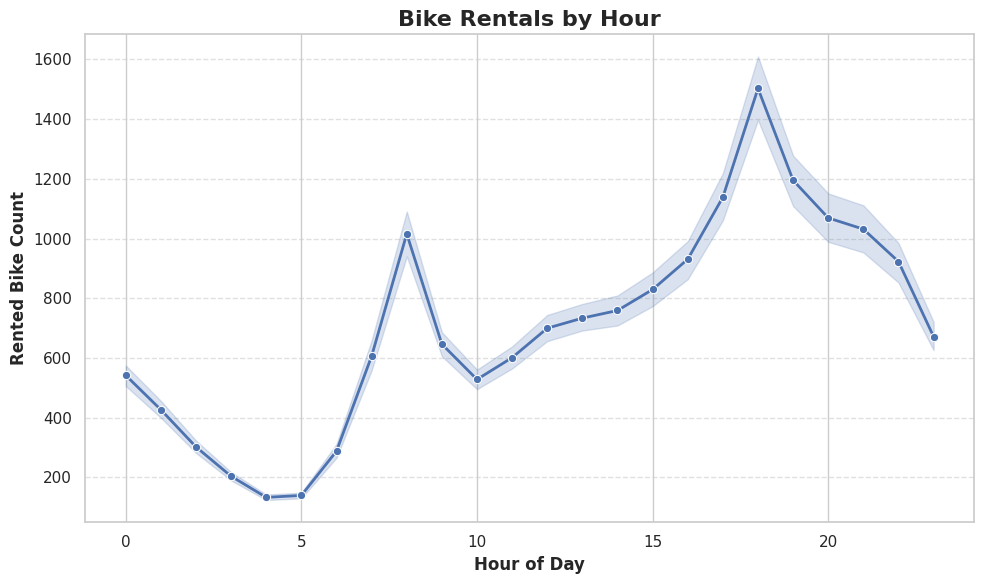

In [ ]:
plt.figure(figsize=(10,6))
sns.set(style="whitegrid")

# Line plot
sns.lineplot(
    data=df,
    x='Hour',
    y='Rented Bike Count',
    marker='o',
    linewidth=2
)

# Titles and labels
plt.title('Bike Rentals by Hour', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12, fontweight='bold')
plt.ylabel('Rented Bike Count', fontsize=12, fontweight='bold')

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

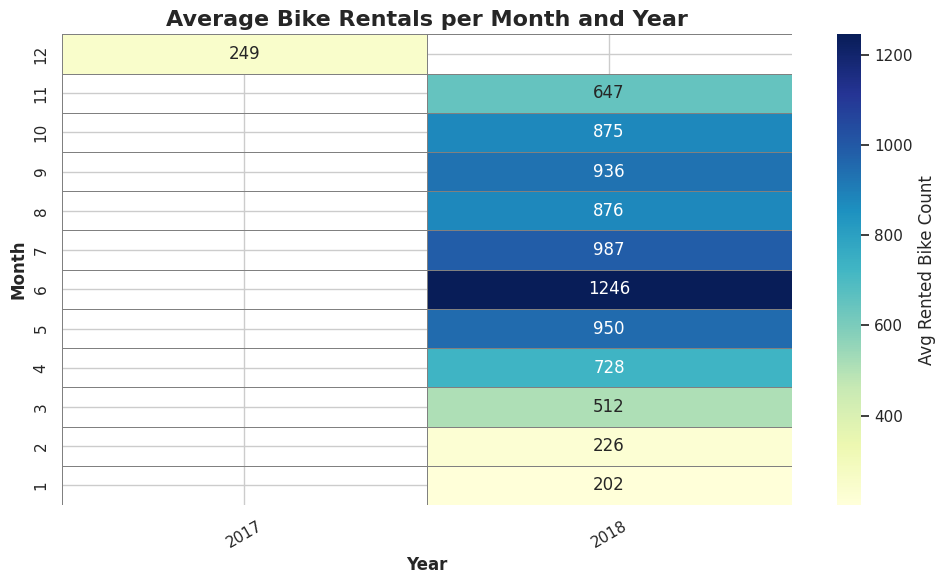

In [ ]:
pivot = df.pivot_table(
    index='Month',
    columns='Year',
    values='Rented Bike Count',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

# Heatmap
ax = sns.heatmap(
    pivot,
    cmap='YlGnBu',
    annot=True,
    fmt='.0f',
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Avg Rented Bike Count'}
)

# Reverse y-axis to have Jan at top
ax.invert_yaxis()

# Titles and labels
plt.title('Average Bike Rentals per Month and Year', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Month', fontsize=12, fontweight='bold')

# Tick styling
plt.xticks(rotation=30, fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

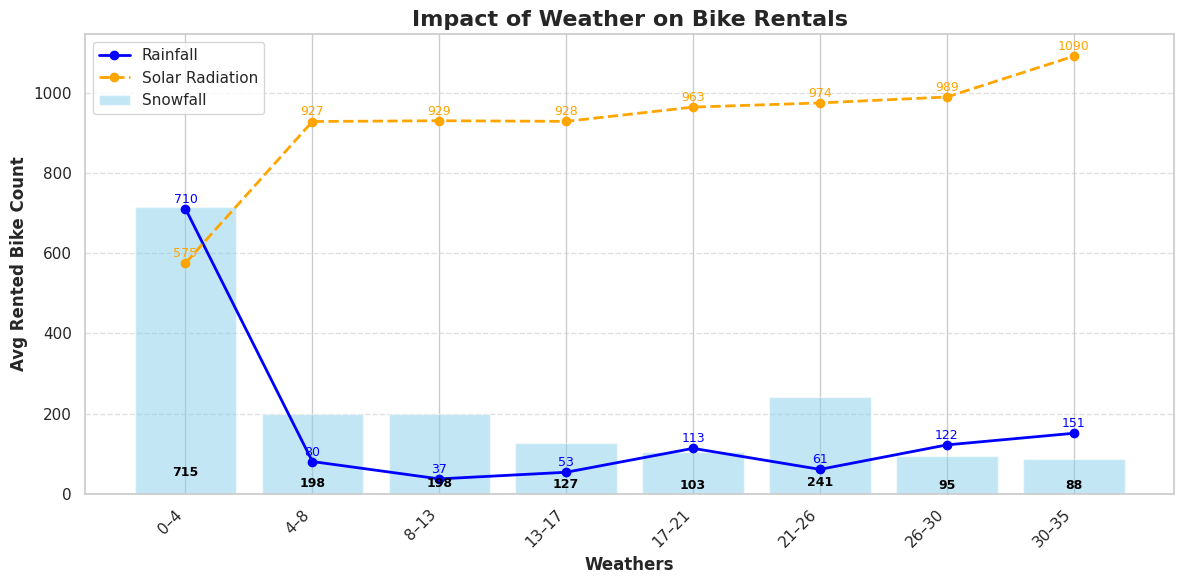

In [ ]:
rain_bins = pd.cut(df['Rainfall(mm)'], bins=8)
snow_bins = pd.cut(df['Snowfall (cm)'], bins=8)
solar_bins = pd.cut(df['Solar Radiation (MJ/m2)'], bins=8)

# --------------------------
# 2️⃣ Aggregate mean rentals per bin
# --------------------------
rain = df.groupby(rain_bins, observed=True)['Rented Bike Count'].mean()
snow = df.groupby(snow_bins, observed=True)['Rented Bike Count'].mean()
solar = df.groupby(solar_bins, observed=True)['Rented Bike Count'].mean()

# --------------------------
# 3️⃣ Create x-axis labels (0–5, 5–10, etc.)
# --------------------------
x_labels = [f'{int(interval.left)}–{int(interval.right)}' for interval in rain.index]
x = np.arange(len(x_labels))

# --------------------------
# 4️⃣ Plot
# --------------------------
fig, ax = plt.subplots(figsize=(12,6))

# Snowfall → BAR
bars = ax.bar(x, snow.values, alpha=0.5, color='skyblue', label='Snowfall')

# Rainfall → LINE
ax.plot(x, rain.values, marker='o', linewidth=2, color='blue', label='Rainfall')

# Solar Radiation → LINE
ax.plot(x, solar.values, marker='o', linestyle='--', linewidth=2, color='orange', label='Solar Radiation')

# --------------------------
# 5️⃣ Add values on bars/lines
# --------------------------
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height * 0.05,
        f'{int(height)}',
        ha='center', va='bottom', fontsize=9, fontweight='bold', color='black'
    )

for i, y in enumerate(rain.values):
    ax.text(x[i], y + 15, f'{int(y)}', ha='center', fontsize=9, color='blue')

for i, y in enumerate(solar.values):
    ax.text(x[i], y + 15, f'{int(y)}', ha='center', fontsize=9, color='orange')

# --------------------------
# 6️⃣ Format axes, title, grid
# --------------------------
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45, ha='right')
plt.title('Impact of Weather on Bike Rentals', fontsize=16, fontweight='bold')
plt.xlabel('Weathers', fontsize=12, fontweight='bold')
plt.ylabel('Avg Rented Bike Count', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

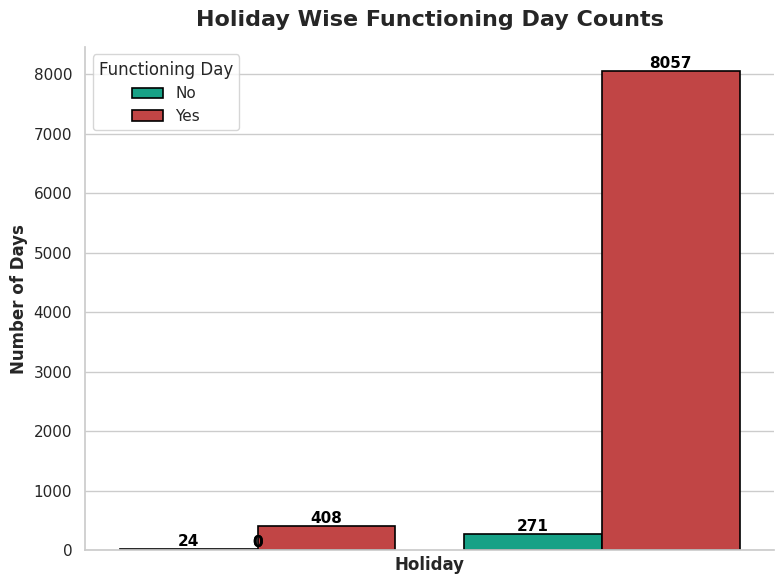

In [ ]:
a = df.groupby(['Holiday', 'Functioning Day']).size().reset_index(name='Count')

sns.set_style("whitegrid")
plt.figure(figsize=(8,6))

# Create barplot
bar = sns.barplot(
    data=a,
    x='Holiday',
    y='Count',
    hue='Functioning Day',
    palette=['#00b894', '#d63031'],  # green/red
    edgecolor='black',
    linewidth=1.2
)

# Add value labels
for p in bar.patches:
    height = p.get_height()
    bar.annotate(f'{int(height)}',
                 (p.get_x() + p.get_width() / 2., height + 0.5),  # slightly above bar
                 ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

# Titles and labels
plt.title('Holiday Wise Functioning Day Counts', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Holiday', fontsize=12, fontweight='bold')
plt.ylabel('Number of Days', fontsize=12, fontweight='bold')

# Rotate x-axis labels if needed
plt.xticks([])

# Legend outside plot
plt.legend(title='Functioning Day', title_fontsize=12, fontsize=11, loc='upper left', frameon=True)

# Optional: Remove top and right spines for cleaner look
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_24755/463559436.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  violin = sns.violinplot(


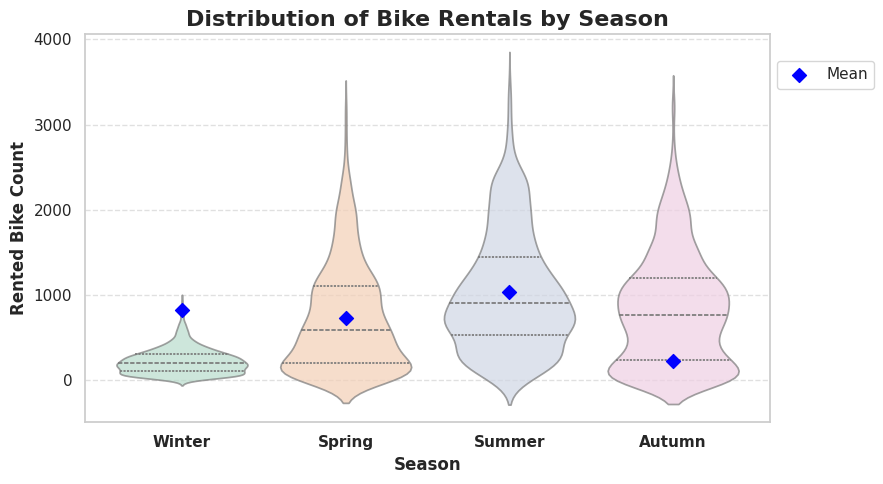

In [ ]:
plt.figure(figsize=(9,5))
sns.set_style("whitegrid")

# Violin plot (no swarm, fast)
violin = sns.violinplot(
    data=df,
    x='Seasons',
    y='Rented Bike Count',
    palette='Pastel2',
    inner='quartile',
    # new parameter to replace scale='width'
    width=0.8
)

# Make violins slightly transparent
for pc in violin.collections:
    pc.set_alpha(0.7)

# Overlay mean points manually
means = df.groupby('Seasons')['Rented Bike Count'].mean().values
for i, mean in enumerate(means):
    plt.scatter(i, mean, color='blue', marker='D', s=50, zorder=3, label='Mean' if i==0 else "")

# Titles and labels
plt.title('Distribution of Bike Rentals by Season', fontsize=16, fontweight='bold')
plt.xlabel('Season', fontsize=12, fontweight='bold')
plt.ylabel('Rented Bike Count', fontsize=12, fontweight='bold')

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11)

# Legend for mean points
plt.legend(
    bbox_to_anchor=(1, 0.95),  # (x, y) outside the plot
    fontsize=11
             )

plt.tight_layout()
plt.show()

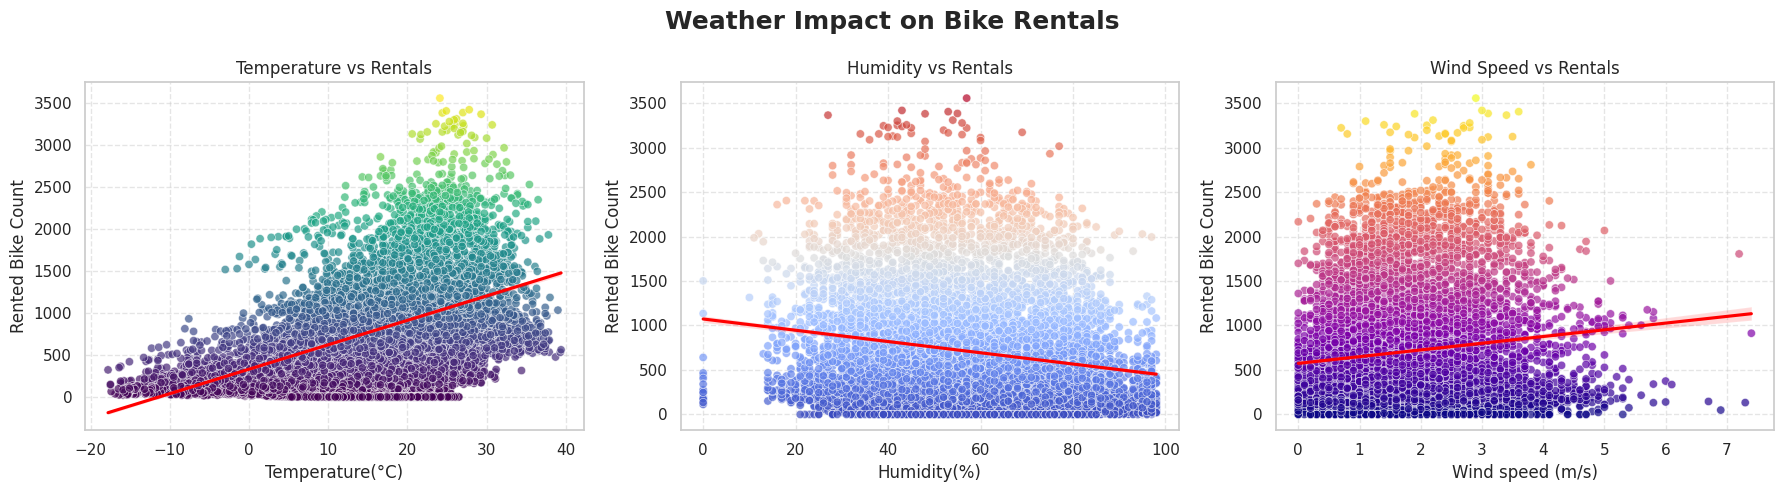

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# 1️⃣ Temperature vs Rentals
sns.scatterplot(
    data=df,
    x='Temperature(°C)',
    y='Rented Bike Count',
    hue='Rented Bike Count',
    palette='viridis',
    alpha=0.7,
    legend=False,
    ax=axes[0]
)
sns.regplot(data=df, x='Temperature(°C)', y='Rented Bike Count',
            scatter=False, color='red', ax=axes[0])
axes[0].set_title('Temperature vs Rentals')


# 2️⃣ Humidity vs Rentals
sns.scatterplot(
    data=df,
    x='Humidity(%)',
    y='Rented Bike Count',
    hue='Rented Bike Count',
    palette='coolwarm',
    alpha=0.7,
    legend=False,
    ax=axes[1]
)
sns.regplot(data=df, x='Humidity(%)', y='Rented Bike Count',
            scatter=False, color='red', ax=axes[1])
axes[1].set_title('Humidity vs Rentals')


# 3️⃣ Wind Speed vs Rentals
sns.scatterplot(
    data=df,
    x='Wind speed (m/s)',
    y='Rented Bike Count',
    hue='Rented Bike Count',
    palette='plasma',
    alpha=0.7,
    legend=False,
    ax=axes[2]
)
sns.regplot(data=df, x='Wind speed (m/s)', y='Rented Bike Count',
            scatter=False, color='red', ax=axes[2])
axes[2].set_title('Wind Speed vs Rentals')


# Common styling
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Weather Impact on Bike Rentals', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


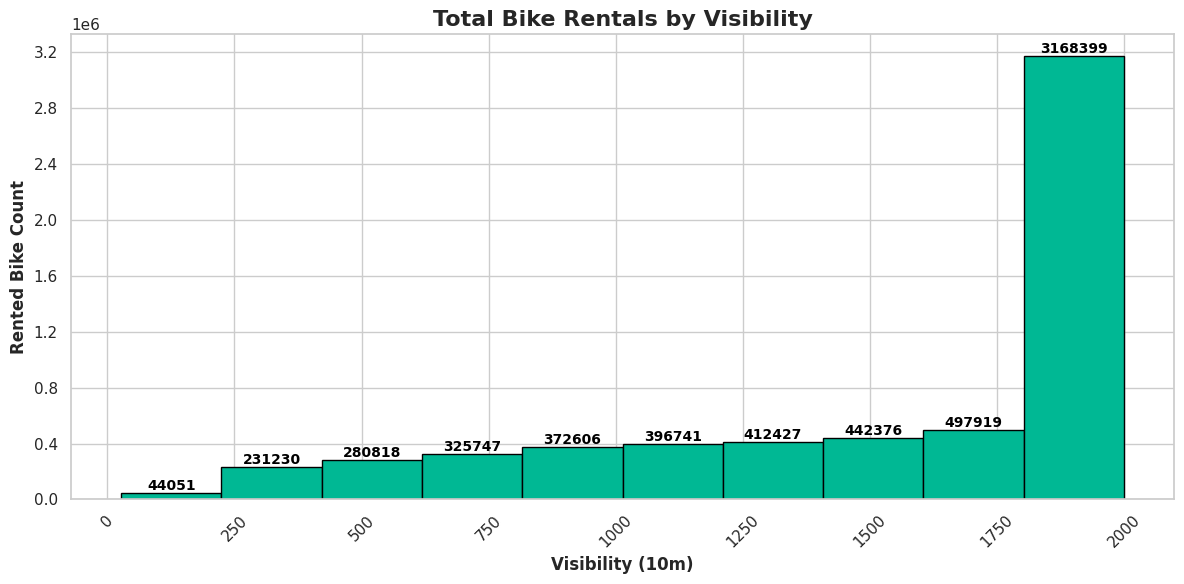

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

plt.figure(figsize=(12,6))

# True histogram: sum of bike rentals per visibility bin
counts, bins, patches = plt.hist(
    df['Visibility (10m)'],          # X-axis: visibility
    bins=10,                          # number of bins
    weights=df['Rented Bike Count'],  # Y-axis: total rentals
    color='#00b894',
    edgecolor='black'
)

# Add integer counts on top of bars
for count, patch in zip(counts, patches):
    plt.text(
        patch.get_x() + patch.get_width()/2,
        count,
        f'{int(round(count))}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

# Y-axis as integers
plt.gca().yaxis.set_major_locator(mtick.MaxNLocator(integer=True))

# Titles & labels
plt.title('Total Bike Rentals by Visibility', fontsize=16, fontweight='bold')
plt.xlabel('Visibility (10m)', fontsize=12, fontweight='bold')
plt.ylabel('Rented Bike Count', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

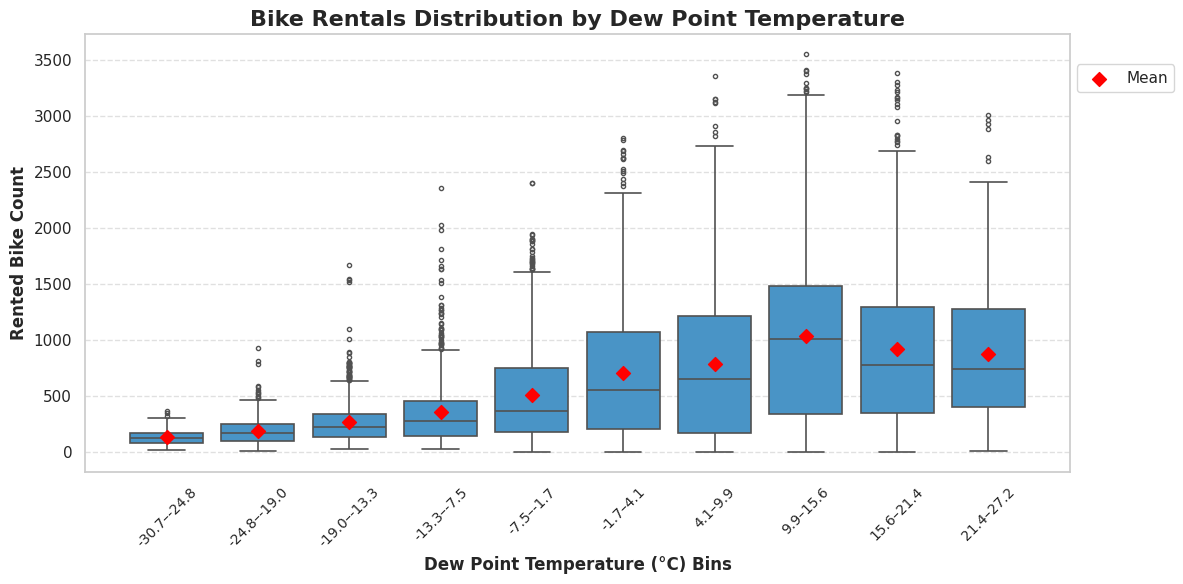

In [ ]:
plt.figure(figsize=(12,6))
sns.set_style("whitegrid")

# Create bins (categorical, no column added to df)
bins = pd.cut(df['Dew point temperature(°C)'], bins=10)

# Generate readable x-axis labels
bin_labels = [f"{round(interval.left,1)}–{round(interval.right,1)}" for interval in bins.cat.categories]

# Boxplot
box = sns.boxplot(
    x=bins,
    y='Rented Bike Count',
    data=df,
    color='#3498db',
    fliersize=3,
    linewidth=1.2
)

# Overlay mean points
means = df.groupby(bins, observed=True)['Rented Bike Count'].mean().values
plt.scatter(
    range(len(means)),
    means,
    color='red',
    marker='D',
    s=50,
    zorder=3,
    label='Mean'
)

# Replace x-axis labels with readable ones
plt.xticks(ticks=range(len(bin_labels)), labels=bin_labels, rotation=45, fontsize=10)
plt.yticks(fontsize=11)
plt.xlabel('Dew Point Temperature (°C) Bins', fontsize=12, fontweight='bold')
plt.ylabel('Rented Bike Count', fontsize=12, fontweight='bold')
plt.title('Bike Rentals Distribution by Dew Point Temperature', fontsize=16, fontweight='bold')

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Legend
plt.legend(
    loc='center left',
    bbox_to_anchor=(1, 0.9),
    fontsize=11
)

plt.tight_layout()
plt.show()

In [ ]:
df.sample(5)

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Day,Month,Year
172,2017-12-08,71,4,-5.3,53,2.4,1936,-13.4,0.00,0.0,0.0,Winter,No Holiday,Yes,8,12,2017
8693,2018-11-28,140,5,3.0,34,1.1,1032,-11.3,0.00,0.0,0.0,Autumn,No Holiday,Yes,28,11,2018
5335,2018-07-11,303,7,24.6,97,0.3,180,24.0,0.07,0.5,0.0,Summer,No Holiday,Yes,11,7,2018
4845,2018-06-20,2246,21,21.6,74,3.3,758,16.7,0.00,0.0,0.0,Summer,No Holiday,Yes,20,6,2018
7937,2018-10-27,1176,17,9.5,34,5.7,2000,-5.6,0.45,0.0,0.0,Autumn,No Holiday,Yes,27,10,2018


In [ ]:
# NewSeoulBikeData = df.to_csv('/content/drive/MyDrive/Project/CSV Files/NewSeoulBikeData.csv')